In [38]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

In [39]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

# 1. Seed fix karna taaki har baar same realistic data bane
np.random.seed(42)

# 2. 200 students ke liye 4 distinct clusters generate karna
# CGPA range ~ 4.0 se 10.0 aur IQ range ~ 70 se 140
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.6, random_state=42)

# Data ko realistic CGPA aur IQ scale par transform karna
cgpa = np.interp(X[:, 0], (X[:, 0].min(), X[:, 0].max()), (4.5, 9.8)).round(2)
iq = np.interp(X[:, 1], (X[:, 1].min(), X[:, 1].max()), (75, 135)).astype(int)

# 3. DataFrame banana (Bilkul image wale layout jaisa)
df = pd.DataFrame({'cgpa': cgpa, 'iq': iq})



print("Shape of data is:", df.shape)
print("\nTop 5 Rows:")
print(df.head())

Shape of data is: (200, 2)

Top 5 Rows:
   cgpa   iq
0  9.70  108
1  6.02  131
2  4.97   77
3  4.65   76
4  4.84   80


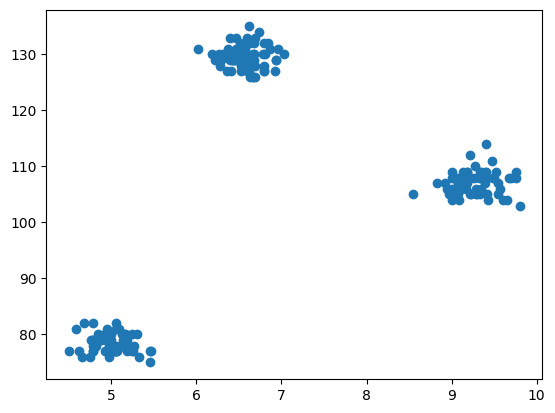

In [40]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'], df['iq'])

In [41]:
from sklearn.cluster import KMeans


wcss = []
for i in range(1,11):
  km = KMeans(n_clusters=i, random_state=42)
  km.fit(df)
  wcss.append(km.inertia_)

In [42]:
wcss

[89055.4309155,
 28627.235632197797,
 710.2016504522837,
 540.7243395599374,
 437.76356906082833,
 271.4434942038881,
 219.52278696072463,
 159.02455693305848,
 119.27144666617393,
 97.38600079778696]

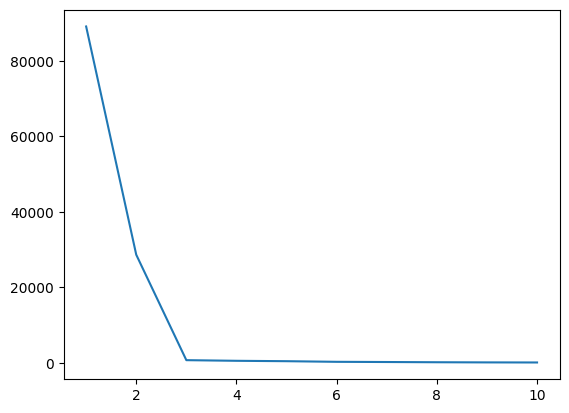

In [43]:
plt.plot(range(1,11), wcss)

In [44]:
X = df.iloc[:, :].values

km = KMeans(n_clusters=3)
y_mean = km.fit_predict(X)

In [45]:
y_mean

array([1, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 0, 2, 1, 2, 1, 1,
       2, 0, 2, 0, 0, 2, 0, 1, 1, 1, 2, 2, 0, 0, 2, 0, 2, 0, 1, 0, 2, 1,
       2, 1, 1, 2, 1, 0, 2, 0, 2, 0, 0, 0, 2, 1, 0, 1, 2, 0, 2, 2, 2, 2,
       0, 0, 2, 0, 0, 2, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 2, 2, 2, 2, 0,
       1, 2, 1, 0, 0, 0, 1, 2, 0, 1, 1, 0, 2, 2, 0, 2, 0, 1, 2, 1, 1, 2,
       1, 1, 0, 2, 0, 2, 2, 0, 0, 0, 2, 1, 0, 2, 2, 1, 0, 0, 1, 0, 1, 2,
       0, 2, 2, 1, 1, 1, 0, 1, 0, 0, 2, 1, 1, 0, 1, 2, 2, 1, 0, 2, 1, 2,
       1, 2, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 1, 0, 2, 1, 2, 0, 1, 2, 0, 1,
       0, 0, 0, 1, 0, 1, 2, 2, 2, 0, 1, 1, 1, 0, 0, 1, 2, 2, 0, 2, 0, 0,
       1, 1], dtype=int32)

In [46]:
X[y_mean==0].shape # try 1 and 2

(67, 2)

In [47]:
X[y_mean == 1, 0] # extract first value
X[y_mean==1,1] # extract second value

array([108., 112., 107., 109., 109., 107., 107., 104., 109., 106., 104.,
       106., 103., 106., 104., 105., 105., 105., 105., 108., 109., 108.,
       108., 114., 105., 105., 105., 106., 110., 108., 108., 108., 108.,
       107., 108., 109., 108., 109., 107., 108., 108., 105., 108., 106.,
       107., 108., 107., 107., 111., 106., 107., 105., 105., 108., 109.,
       106., 109., 108., 104., 109., 107., 108., 108., 104., 107., 109.,
       108.])

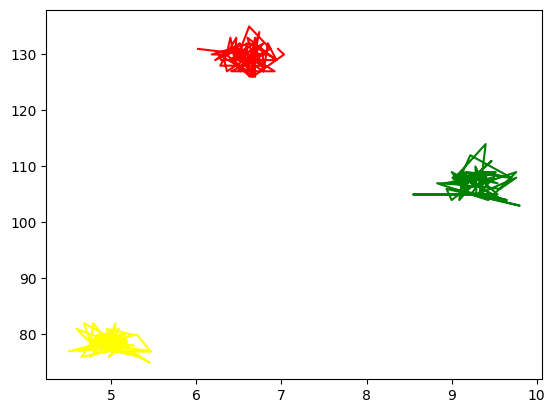

In [48]:
plt.plot(X[y_mean==0,0], X[y_mean==0,1], 'red')
plt.plot(X[y_mean==1,0], X[y_mean==1,1], 'green')
plt.plot(X[y_mean==2,0], X[y_mean==2,1], 'yellow')


In [50]:
# K-Means on 3-D Data

from sklearn.datasets import make_blobs

centroids = [(-5, -5, 5), (5, 5, -5), (3.5, -2.5, 4), (-2.5, 2.5, -4)]
cluster_std = [1, 1, 1, 1]

X, y = make_blobs(n_samples=200, cluster_std=cluster_std, centers=centroids, n_features=3, random_state=1)

In [53]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()